# 基地台網路模擬系統

本筆記本實現了一個蜂巢式網路系統的模擬，包含：
- 六邊形基地台佈局
- 使用者分布
- SINR計算
- 能耗模型
- 網路性能評估

In [209]:
# 導入所需套件
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
import math
from typing import List, Tuple

## 1. 系統參數設定

In [210]:
class SystemParameters:
    def __init__(self):
        self.BS_COUNT = 37      # 基地台數量
        self.RADIUS = 500       # 基地台間距(m)
        self.UE_COUNT = 100     # 使用者數量
        self.LAMBDA = 0.1       # 封包到達率(封包/ms)
        self.NOISE_POWER = -174 # 噪聲功率(dBm)
        self.BS_POWER = 43      # 基地台發射功率(dBm)
        self.PATH_LOSS_EXP = 3.5 # 路徑損耗指數

## 2. 座標轉換與六邊形網格函數

In [211]:
def axial_to_xy(u: int, v: int, k: float) -> Tuple[float, float]:
    # 你也可以用 x = (2*sqrt(3)/3)*k*(u+0.5*v); y=k*v 的 pointy-top 版本
    x = (math.sqrt(3)/2.0) * k * u
    y = k * (v + 0.5 * u)
    return (x, y)

# 正確的「沿環」方向（counterclockwise），會維持 hex distance = i
RING_DIRS = [(1,-1), (1,0), (0,-1), (-1,1), (-1,0), (0,1)]

def hex_ring(i: int, k: float) -> List[Tuple[float, float]]:
    if i == 0:
        return [(0.0, 0.0)]
    u, v = 0, i          # 從「正上方」開始
    pts = []
    for du, dv in RING_DIRS:
        for _ in range(i):
            pts.append(axial_to_xy(u, v, k))  # 先記錄，再移動
            u += du
            v += dv
    return pts

def hex_disk(layers: int, k: float) -> List[Tuple[float, float]]:
    pts = []
    for r in range(layers + 1):
        pts.extend(hex_ring(r, k))
    return pts

## 3. 基地台與使用者位置生成

In [212]:
def generate_hex_grid(layers: int = None) -> np.ndarray:
    params = SystemParameters()
    if layers is None:
        n = 0
        while 1 + 3 * n * (n + 1) < params.BS_COUNT:
            n += 1
        layers = n
    
    k = params.RADIUS
    pts = hex_disk(layers, k)
    pts = pts[: params.BS_COUNT]
    return np.array(pts)

def generate_ue_positions(params):
    area_radius = 2000
    angles = np.random.uniform(0, 2*np.pi, params.UE_COUNT)
    radii = np.random.uniform(0, area_radius, params.UE_COUNT)
    x = radii * np.cos(angles)
    y = radii * np.sin(angles)
    return np.column_stack((x, y))

## 4. SINR與功率消耗計算

In [213]:
def calculate_sinr(ue_pos, bs_positions, active_bs, params):
    distances = np.sqrt(np.sum((bs_positions - ue_pos)**2, axis=1))
    distances = np.maximum(distances, 1e-3)
    path_loss = 10 * params.PATH_LOSS_EXP * np.log10(distances)
    received_power = params.BS_POWER - path_loss
    
    received_power[~active_bs] = -np.inf
    
    if np.all(np.isneginf(received_power)):
        return -np.inf, -1

    max_power_idx = np.argmax(received_power)
    interference = np.sum(10**(received_power/10)) - 10**(received_power[max_power_idx]/10)
    
    signal = 10**(received_power[max_power_idx]/10)
    noise = 10**(params.NOISE_POWER/10)
    
    sinr = 10 * np.log10(signal / (interference + noise))
    return sinr, max_power_idx

def calculate_power_consumption(active_bs, traffic_load):
    P_sleep = 10   # 休眠功耗(W)
    P_active = 100 # 活躍功耗(W)
    
    total_power = np.sum(active_bs * (P_active * traffic_load + P_active)) + \
                 np.sum(~active_bs * P_sleep)
    return total_power

## 5. 視覺化函數

In [214]:
def visualize_bs_layout(bs_positions, annotate=False):
    plt.figure(figsize=(8, 8))
    bs_positions = np.asarray(bs_positions)
    plt.scatter(bs_positions[:, 0], bs_positions[:, 1], c='blue', marker='o', label='Base Stations')
    if annotate:
        for i, (x, y) in enumerate(bs_positions):
            plt.text(x, y, str(i), fontsize=8, ha='center', va='center')
    plt.title('基地台佈局')
    plt.xlabel('X 座標 (m)')
    plt.ylabel('Y 座標 (m)')
    plt.axhline(0, color='grey', lw=0.5, ls='--')
    plt.axvline(0, color='grey', lw=0.5, ls='--')
    plt.grid(True, ls=':')
    plt.axis('equal')
    plt.legend()
    plt.show()

def visualize_hex_ring(i: int, k: float, annotate: bool = False):
    pts = np.array(hex_ring(i, k))
    plt.figure(figsize=(6, 6))
    if pts.size > 0:
        plt.scatter(pts[:, 0], pts[:, 1], c='C0', s=60, label=f'Ring {i}')
    plt.scatter(0.0, 0.0, c='red', s=50, label='Center')
    if annotate and pts.size > 0:
        for idx, (x, y) in enumerate(pts):
            plt.text(x, y, str(idx), fontsize=8, ha='center', va='center')
    plt.title(f'六邊形環 i={i}, k={k}')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.grid(True, ls=':')
    plt.axis('equal')
    plt.legend()
    plt.show()

def visualize_hex_disk(layers: int, k: float, annotate: bool = False):
    pts = np.array(hex_disk(layers, k))
    plt.figure(figsize=(7, 7))
    if pts.size > 0:
        plt.scatter(pts[:, 0], pts[:, 1], c='C1', s=50, label=f'Disk layers={layers}')
    plt.scatter(0.0, 0.0, c='red', s=60, label='Center')
    if annotate and pts.size > 0:
        for idx, (x, y) in enumerate(pts):
            plt.text(x, y, str(idx), fontsize=7, ha='center', va='center')
    plt.title(f'六邊形區域 layers={layers}, k={k}')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.grid(True, ls=':')
    plt.axis('equal')
    plt.legend()
    plt.show()

## 6. 模擬函數

In [215]:
def simulate(params, bs_positions, ue_positions, active_bs, simulation_time=1000):
    traffic_load = np.zeros(params.BS_COUNT)
    successful_transmissions = 0
    total_attempts = 0
    
    for t in range(simulation_time):
        packets = poisson.rvs(params.LAMBDA, size=params.UE_COUNT)
        
        for ue_idx, ue_pos in enumerate(ue_positions):
            if packets[ue_idx] > 0:
                sinr, serving_bs = calculate_sinr(ue_pos, bs_positions, active_bs, params)
                
                if sinr > 0:  # SINR門檻為0dB
                    successful_transmissions += packets[ue_idx]
                    traffic_load[serving_bs] += packets[ue_idx]
                
                total_attempts += packets[ue_idx]
    
    success_rate = successful_transmissions / total_attempts if total_attempts > 0 else 0
    power_consumption = calculate_power_consumption(active_bs, traffic_load/simulation_time)
    
    return success_rate, power_consumption

def main():
    params = SystemParameters()
    bs_positions = generate_hex_grid()
    ue_positions = generate_ue_positions(params)
    
    strategies = []
    for active_ratio in np.arange(0.4, 1.1, 0.1):
        active_bs = np.random.choice([True, False], 
                                   size=params.BS_COUNT, 
                                   p=[active_ratio, 1-active_ratio])
        
        success_rate, power = simulate(params, bs_positions, ue_positions, active_bs)
        strategies.append({
            'active_ratio': active_ratio,
            'success_rate': success_rate,
            'power': power
        })
    
    plt.figure(figsize=(10, 6))
    active_ratios = [s['active_ratio'] for s in strategies]
    success_rates = [s['success_rate'] for s in strategies]
    powers = [s['power'] for s in strategies]
    
    plt.subplot(1, 2, 1)
    plt.plot(active_ratios, success_rates, 'b-o')
    plt.xlabel('基地台開啟比例')
    plt.ylabel('成功率')
    
    plt.subplot(1, 2, 2)
    plt.plot(active_ratios, powers, 'r-o')
    plt.xlabel('基地台開啟比例')
    plt.ylabel('功率消耗 (W)')
    
    plt.tight_layout()
    plt.show()

## 7. 執行模擬

/var/folders/4w/k961rvbd56n2mvq8sj_8_zsw0000gn/T/ipykernel_8941/950412675.py:57: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4w/k961rvbd56n2mvq8sj_8_zsw0000gn/T/ipykernel_8941/950412675.py:57: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4w/k961rvbd56n2mvq8sj_8_zsw0000gn/T/ipykernel_8941/950412675.py:57: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4w/k961rvbd56n2mvq8sj_8_zsw0000gn/T/ipykernel_8941/950412675.py:57: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4w/k961rvbd56n2mvq8sj_8_zsw0000gn/T/ipykernel_8941/950412675.py:57: UserWarning: Glyph 21855 (\N{CJK UNIFIED IDEOGRAPH-555F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4w/k961rvbd56n2mv

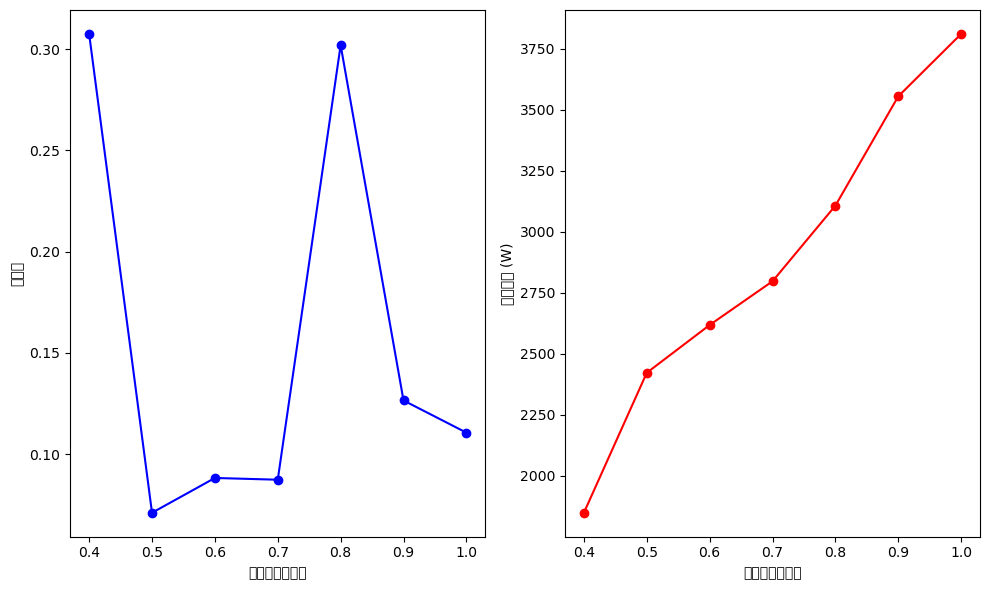

In [216]:
if __name__ == "__main__":
    main()

# 基地台佈局視覺化展示

展示以下內容：
1. 完整的基地台佈局
2. 使用者分布
3. 標註基地台編號

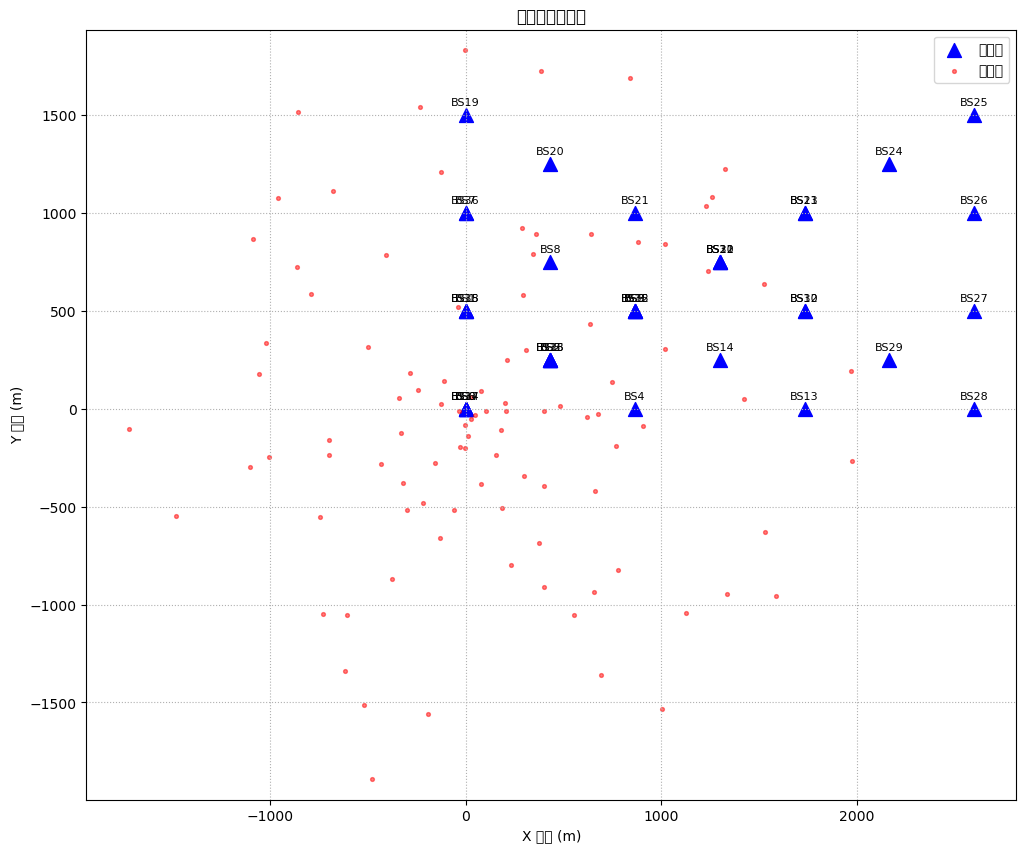

基地台數量: 37
使用者數量: 100


In [217]:
# 示範基地台佈局
params = SystemParameters()
bs_positions = generate_hex_grid()
ue_positions = generate_ue_positions(params)

# 繪製基地台和使用者
plt.figure(figsize=(12, 10))
plt.scatter(bs_positions[:, 0], bs_positions[:, 1], 
           c='blue', marker='^', s=100, label='基地台')
plt.scatter(ue_positions[:, 0], ue_positions[:, 1], 
           c='red', marker='.', s=30, alpha=0.5, label='使用者')

# 標註基地台編號
for i, (x, y) in enumerate(bs_positions):
    plt.text(x, y+50, f'BS{i}', fontsize=8, ha='center')

# 美化圖表
plt.title('蜂巢式網路佈局')
plt.xlabel('X 座標 (m)')
plt.ylabel('Y 座標 (m)')
plt.grid(True, linestyle=':')
plt.axis('equal')
plt.legend()
plt.show()

print(f'基地台數量: {len(bs_positions)}')
print(f'使用者數量: {len(ue_positions)}')